## VIVA AGENT

In [27]:
from typing import List
from typing import Literal
from typing import TypedDict
from langgraph.graph import START, END, StateGraph
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

llm = ChatOllama(model="llama3.2")

class State(TypedDict):
    phase : Literal["INTRO","QUESTIONING","GRADING","FINISHED"]
    question_count:int
    transcript: List[str]
    score: float
    current_answer: str

def intro_node(state: State):
    print("Agent: Welcome to your Viva. Let's begin.")
    # ONLY greeting here
    return {"phase": "QUESTIONING", "transcript": ["Agent: Welcome to your Viva."]}

def questioning_node(state: State):
    # Retrieve and Ask ONLY here
    print(f"Agent: Asking Question {state['question_count'] + 1}...")
    
    query = f"Provide a technical question based on this syllabus for Viva Question {state['question_count'] + 1}"
    context_docs = retriever.invoke(query)
    context_text = "\n\n".join([doc.page_content for doc in context_docs])
    
    prompt = ChatPromptTemplate.from_template(
        "You are a strict examiner. Use the following syllabus content to ask exactly one technical question:\n\n"
        "{context}\n\n"
        "Question: "
    )
    chain = prompt | llm
    response = chain.invoke({"context": context_text})
    
    print(f"\nAgent: {response.content}")
    
    # Return the incremented count and update the transcript
    return {
        "question_count": state['question_count'] + 1, 
        "transcript": state['transcript'] + [response.content]
    }

def grading_node(state: State):
    print("\nAgent: Grading your responses based on syllabus...")
    
    transcript_text = "\n".join(state['transcript'])
    
    prompt = f"""
    You are an expert Professor. Grade the following viva transcript on a scale of 0-100.
    
    Transcript:
    {transcript_text}
    
    Analyze the technical depth and accuracy of the student's answers.
    Return ONLY a numeric score (e.g., '78' or '92'). Do not add any text or explanation.
    """
    
    response = llm.invoke(prompt)
    
    # Extract the number from the response
    try:
        score = float(''.join(filter(lambda x: x.isdigit() or x == '.', response.content)))
    except:
        score = 0.0 
        
    return {"phase": "FINISHED", "score": score}

def should_continue(state:State):
    if state.get("question_count", 0) >= 3:
        return "grading"
    return "questioning"


workflow = StateGraph(State)

workflow.add_node("intro",intro_node)
workflow.add_node("questioning",questioning_node)
workflow.add_node("grading",grading_node)

workflow.set_entry_point("intro")
workflow.add_edge("intro","questioning")
workflow.add_conditional_edges(
    "questioning",
    should_continue,
    {
        "grading":"grading",
        "questioning":"questioning"
    }
)
workflow.add_edge("grading",END)

app = workflow.compile(
    checkpointer=memory, 
    interrupt_before=["questioning","grading"]
)

    

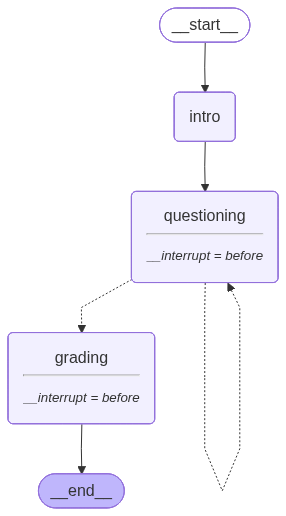

In [28]:
app

In [29]:
config = {"configurable": {"thread_id": "viva_1"}}
initial_input = {"phase": "INTRO", "question_count": 0, "transcript": [], "score": 0.0, "current_answer": ""}

for event in app.stream(initial_input, config=config):
    print(event)

for event in app.stream(None, config=config):
    print(event)

Agent: Welcome to your Viva. Let's begin.
{'intro': {'phase': 'QUESTIONING', 'transcript': ['Agent: Welcome to your Viva.']}}
{'__interrupt__': ()}
Agent: Asking Question 1...

Agent: Here's your technical question:

What is the primary difference between Programmed I/O and Interrupt-driven I/O in terms of how the processor handles the completion of I/O operations?
{'questioning': {'question_count': 1, 'transcript': ['Agent: Welcome to your Viva.', "Here's your technical question:\n\nWhat is the primary difference between Programmed I/O and Interrupt-driven I/O in terms of how the processor handles the completion of I/O operations?"]}}
{'__interrupt__': ()}


### Answer Q1 :
```In Programmed I/O, the processor wastes cycles by continuously polling (checking) the I/O device's status. In Interrupt-driven I/O, the processor is freed to do other tasks and only pauses to handle the I/O when the device signals that it is ready.```

In [30]:
# 1. Get the current state of the agent
config = {"configurable": {"thread_id": "viva_1"}}
current_state = app.get_state(config)

# 2. Capture answer
student_answer = input("Enter your answer: ")

# 3. Update the state
# Note: we use current_state.values['transcript'] to get the existing list
app.update_state(config, {
    "current_answer": student_answer,
    "transcript": current_state.values['transcript'] + [f"Student: {student_answer}"]
})

# 4. Resume the graph execution
for event in app.stream(None, config=config):
    print(event)

Agent: Asking Question 2...

Agent: Here's your technical question:

What scheduling algorithm would you choose as the CPU-scheduling algorithm in a multi-user operating system, given that you want to ensure fair sharing of CPU resources among multiple processes, while also minimizing the overhead of context switching?

(Note: I'm looking for a specific answer, not just a general direction. Be prepared to provide a detailed explanation.)
{'questioning': {'question_count': 2, 'transcript': ['Agent: Welcome to your Viva.', "Here's your technical question:\n\nWhat is the primary difference between Programmed I/O and Interrupt-driven I/O in terms of how the processor handles the completion of I/O operations?", "Student: In Programmed I/O, the processor wastes cycles by continuously polling (checking) the I/O device's status. In Interrupt-driven I/O, the processor is freed to do other tasks and only pauses to handle the I/O when the device signals that it is ready.", "Here's your technical 

### Answer Q2:
```
I would choose the Multilevel Feedback Queue (MLFQ) algorithm, or a heavily optimized variation like the Completely Fair Scheduler (CFS) used in modern Linux systems, to fulfill these exact requirements```

In [31]:
# 1. Provide the answer for Question 2
student_answer_2 = input("Enter your answer for Q2: ")

# 2. Update state with the new answer
config = {"configurable": {"thread_id": "viva_1"}}
current_state = app.get_state(config)

app.update_state(config, {
    "current_answer": student_answer_2,
    "transcript": current_state.values['transcript'] + [f"Student: {student_answer_2}"]
})

# 3. Resume the graph
for event in app.stream(None, config=config):
    print(event)

Agent: Asking Question 3...

Agent: Here's your technical question:

Consider a multi-processor system using a Round-Robin scheduling algorithm, where each processor has an unlimited number of buffers. What would happen to the average waiting time for a process if the number of buffers is increased from 10 to 100 while keeping the total available time equal?
{'questioning': {'question_count': 3, 'transcript': ['Agent: Welcome to your Viva.', "Here's your technical question:\n\nWhat is the primary difference between Programmed I/O and Interrupt-driven I/O in terms of how the processor handles the completion of I/O operations?", "Student: In Programmed I/O, the processor wastes cycles by continuously polling (checking) the I/O device's status. In Interrupt-driven I/O, the processor is freed to do other tasks and only pauses to handle the I/O when the device signals that it is ready.", "Here's your technical question:\n\nWhat scheduling algorithm would you choose as the CPU-scheduling alg

### Answer Q3:
```Because the total available time (quantum) for process execution is held constant, changing the number of buffers has no effect on the average waiting time. ```

In [32]:
# 1. Provide the answer for Question 2
student_answer_3 = input("Enter your answer for Q3: ")

# 2. Update state with the new answer
config = {"configurable": {"thread_id": "viva_1"}}
current_state = app.get_state(config)

app.update_state(config, {
    "current_answer": student_answer_3,
    "transcript": current_state.values['transcript'] + [f"Student: {student_answer_3}"]
})

# 3. Resume the graph
for event in app.stream(None, config=config):
    print(event)


Agent: Grading your responses based on syllabus...
{'grading': {'phase': 'FINISHED', 'score': 77.0}}


In [33]:
final_state = app.get_state(config)
print(f"\nFinal Score: {final_state.values.get('score')}")
print(f"Transcript: {final_state.values.get('transcript')}")


Final Score: 77.0
Transcript: ['Agent: Welcome to your Viva.', "Here's your technical question:\n\nWhat is the primary difference between Programmed I/O and Interrupt-driven I/O in terms of how the processor handles the completion of I/O operations?", "Student: In Programmed I/O, the processor wastes cycles by continuously polling (checking) the I/O device's status. In Interrupt-driven I/O, the processor is freed to do other tasks and only pauses to handle the I/O when the device signals that it is ready.", "Here's your technical question:\n\nWhat scheduling algorithm would you choose as the CPU-scheduling algorithm in a multi-user operating system, given that you want to ensure fair sharing of CPU resources among multiple processes, while also minimizing the overhead of context switching?\n\n(Note: I'm looking for a specific answer, not just a general direction. Be prepared to provide a detailed explanation.)", 'Student: Multilevel Feedback Queue (MLFQ) ', "Here's your technical ques

## Embedding and Vector Store Code

In [12]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

loader = PyPDFLoader("OPERATING-SYSTEMS.pdf")
docs = loader.load()

In [13]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [14]:
from langchain_community.vectorstores import Chroma
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="nomic-embed-text")

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})